In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import ttest_ind, t, sem

def plot_gene_expression_summary(adata, top_genes, category):
    # Préparation des données fondues
    melted = (
        adata[:, top_genes].to_df()
        .assign(**{category: adata.obs[category].values})
        .melt(id_vars=category, var_name="gene", value_name="expression")
    )

    # Détection des niveaux de groupe
    group_levels = (
        list(adata.obs[category].cat.categories)
        if hasattr(adata.obs[category], "cat")
        else sorted(adata.obs[category].unique())
    )

    # Calcul des statistiques
    summary_stats = (
        melted.groupby(["gene", category], observed=False)
        .agg(mean_expression=("expression", "mean"),
             count=("expression", "count"),
             std=("expression", "std"))
        .reset_index()
    )

    summary_stats["std"] = summary_stats["std"].fillna(0.0)
    summary_stats["sem"] = summary_stats["std"] / np.sqrt(summary_stats["count"].clip(lower=1))
    df_dof = (summary_stats["count"] - 1).clip(lower=1)
    summary_stats["ci95"] = t.ppf(0.975, df_dof) * summary_stats["sem"]
    summary_stats.loc[summary_stats["count"] <= 1, "ci95"] = 0.0

    # Pivots
    mean_pivot = (
        summary_stats.pivot(index="gene", columns=category, values="mean_expression")
        .reindex(top_genes)
        .reindex(columns=group_levels)
        .fillna(0.0)
    )
    ci_pivot = (
        summary_stats.pivot(index="gene", columns=category, values="ci95")
        .reindex(top_genes)
        .reindex(columns=group_levels)
        .fillna(0.0)
    )

    # Tests t pour deux groupes
    pvalues = {}
    if len(group_levels) == 2:
        for gene in top_genes:
            gene_vals = melted[melted["gene"] == gene]
            grp1 = gene_vals[gene_vals[category] == group_levels[0]]["expression"]
            grp2 = gene_vals[gene_vals[category] == group_levels[1]]["expression"]
            _, pval = ttest_ind(grp1, grp2, equal_var=False)
            pvalues[gene] = pval

    def star_from_pvalue(p):
        if p < 1e-4:
            return "****"
        if p < 1e-3:
            return "***"
        if p < 1e-2:
            return "**"
        if p < 5e-2:
            return "*"
        return ""

    # Graphique
    x = np.arange(len(top_genes))
    bar_width = 0.35
    fig_bar, ax_bar = plt.subplots(figsize=(14, 6))

    for idx, level in enumerate(group_levels):
        offsets = (idx - (len(group_levels) - 1) / 2) * bar_width
        means = mean_pivot[level].to_numpy()
        cis = ci_pivot[level].to_numpy()
        ax_bar.bar(
            x + offsets,
            means,
            width=bar_width,
            yerr=cis,
            capsize=5,
            label=level,
            alpha=0.8
        )

    if len(group_levels) == 2:
        max_height = (mean_pivot + ci_pivot).values.max()
        for gene_idx, gene in enumerate(top_genes):
            pval = pvalues.get(gene)
            stars = star_from_pvalue(pval) if pval is not None else ""
            if stars:
                positions = x[gene_idx] + np.array(
                    [(i - (len(group_levels) - 1) / 2) * bar_width for i in range(len(group_levels))]
                )
                top_vals = mean_pivot.loc[gene, group_levels].to_numpy() + ci_pivot.loc[gene, group_levels].to_numpy()
                y = top_vals.max() + 0.15 * max_height / 6
                h = 0.05 * max_height
                ax_bar.plot([positions[0], positions[0], positions[1], positions[1]],
                            [y, y + h, y + h, y], color="black", linewidth=1)
                ax_bar.text(positions.mean(), y + h + 0.02 * max_height, stars,
                            ha="center", va="bottom", fontsize=12)

    ax_bar.set_xlabel("Gene")
    ax_bar.set_ylabel("Mean log1p expression")
    ax_bar.set_title(f"Mean log1p expression of top genes by {category} (95% CI)")
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(top_genes, rotation=45, ha="right")
    ax_bar.legend(title=category)
    ax_bar.grid(axis="y", linestyle="--", alpha=0.3)
    ax_bar.set_ylim(0, (mean_pivot + ci_pivot).values.max() * 1.5)

    plt.tight_layout()
    plt.show()

# Set default figure size
# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['axes.titlesize'] = 16
# plt.rcParams['axes.labelsize'] = 12
# plt.rcParams['xtick.labelsize'] = 10
# plt.rcParams['ytick.labelsize'] = 10

In [4]:
adata_sigma = sc.read_h5ad("/mnt/scratch/guillaume/results_dominguez/merge.h5ad")
adata_author = sc.read_h5ad("/mnt/scratch/guillaume/data/dominguez/Dominguez.h5add")

adata_author.X = adata_author.layers["counts"]

adata_sigma.obs_names = [re.sub(r"-[A-Z]+_data", "", name) for name in adata_sigma.obs_names]

In [5]:
adata_sigma.obs

,donor,sex,age,celltype,organ,chemistry,score,proba_target,proba_Monocytes,proba_Macrophages,proba_LymphocytesT,proba_LymphocytesB,proba_Neutrophils,target_mean_expr,Monocytes_mean_expr,Macrophages_mean_expr,LymphocytesT_mean_expr,LymphocytesB_mean_expr,Neutrophils_mean_expr,study
Pan_T7935495_AATCGGTTCAACACTG,A29,Female,Early erythroid,Early erythroid,BMA,5v1,0.043911,0.043923,2.815484e-06,9.257808e-06,0.000000e+00,0.000000,3.035223e-97,1.530583,0.000000,0.000000,0.000000,0.0,0.000000,BMA_data
Pan_T7935495_CACACTCAGTTGAGAT,A29,Female,Early MK,Early MK,BMA,5v1,0.977418,1.000000,1.044482e-03,2.153778e-02,0.000000e+00,0.000000,3.035223e-97,4.934773,1.350555,1.861335,0.000000,0.0,0.000000,BMA_data
Pan_T7935495_CAGTCCTAGGCAATTA,A29,Female,Early erythroid,Early erythroid,BMA,5v1,0.011546,0.011558,2.815484e-06,9.257808e-06,0.000000e+00,0.000000,3.035223e-97,0.836500,0.000000,0.000000,0.000000,0.0,0.000000,BMA_data
Pan_T7935495_CGATGGCCAGGTGGAT,A29,Female,Mast cells,Mast cells,BMA,5v1,0.015744,0.015756,2.815484e-06,9.257808e-06,0.000000e+00,0.000000,6.585487e-45,0.631148,0.000000,0.000000,0.000000,0.0,0.935465,BMA_data
Pan_T7935495_CTGCCTACAATCGAAA,A29,Female,Early MK,Early MK,BMA,5v1,0.971349,1.000000,2.815484e-06,2.864776e-02,0.000000e+00,0.000000,3.035223e-97,6.013752,0.000000,1.915228,0.000000,0.0,0.000000,BMA_data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CZINY-0063_ATGATCGTCCCTATTA,D503,Female,65-70,Early MK,BLD,3,0.993556,0.993566,3.346025e-222,8.783493e-06,7.520394e-114,0.000002,0.000000e+00,6.299258,0.000000,1.855490,0.000000,0.0,0.000000,BLD_data
CZINY-0064_AGAAGTAAGAGTTGTA,D503,Female,65-70,Early MK,BLD,3,0.998106,0.998108,3.346025e-222,9.158698e-07,7.520394e-114,0.000002,0.000000e+00,7.150854,0.000000,1.567213,0.000000,0.0,0.796799,BLD_data
Pan_T7935497_CGTTAGAGTGTAACGG,A29,Female,65-70,Tem/Effector helper T cells,LIV,5v1,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,5.346905,0.000000,0.000000,0.000000,0.0,0.000000,LIV_data
CZI-IA10471911+CZI-IA10472007_ACTTACTGTTCAGGCC,640C,Female,70-74,MEMP,LIV,5v2,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.589437,0.000000,0.908659,0.000000,0.0,0.519234,LIV_data


In [6]:
adata_sumry = ad.AnnData(adata_author.X)

# Add var table
adata_sumry.var_names = adata_author.var_names

# Add UMAP coordinates
adata_sumry.obsm["X_umap"] = adata_author.obsm["X_umap"]

# Add counts table
adata_sumry.layers["raw"] = adata_author.layers["counts"]
adata_sumry.layers["log1p"] = adata_author.X

# Add obs table
adata_sumry.obs_names = adata_author.obs_names
adata_sumry.obs["donor"] = adata_author.obs["Donor"]
adata_sumry.obs["sex"] = adata_author.obs["Sex"]
adata_sumry.obs["age"] = adata_author.obs["Age_range"]
adata_sumry.obs["organ"] = adata_author.obs["Organ"]
adata_sumry.obs["assay"] = adata_author.obs["Chemistry"]
adata_sumry.obs["celltype"] = adata_author.obs["Majority_voting_CellTypist_high"]

adata_sumry.obs["score"] = 0.0
adata_sumry.obs.loc[adata_sigma.obs_names, "score"] = adata_sigma.obs["score"].values

proba_cols = [col for col in adata_sigma.obs.columns if col.startswith("proba_")]
for prob in proba_cols:
    adata_sumry.obs[prob] = 0.0
    adata_sumry.obs.loc[adata_sigma.obs_names, prob] = adata_sigma.obs[prob].values

sc.pp.normalize_total(adata_sumry, target_sum=1e6)
sc.pp.log1p(adata_sumry)
adata_sumry

AnnData object with n_obs × n_vars = 329762 × 36601
    obs: 'donor', 'sex', 'age', 'organ', 'assay', 'celltype', 'score', 'proba_target', 'proba_Monocytes', 'proba_Macrophages', 'proba_LymphocytesT', 'proba_LymphocytesB', 'proba_Neutrophils'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'raw', 'log1p'

# Score plot

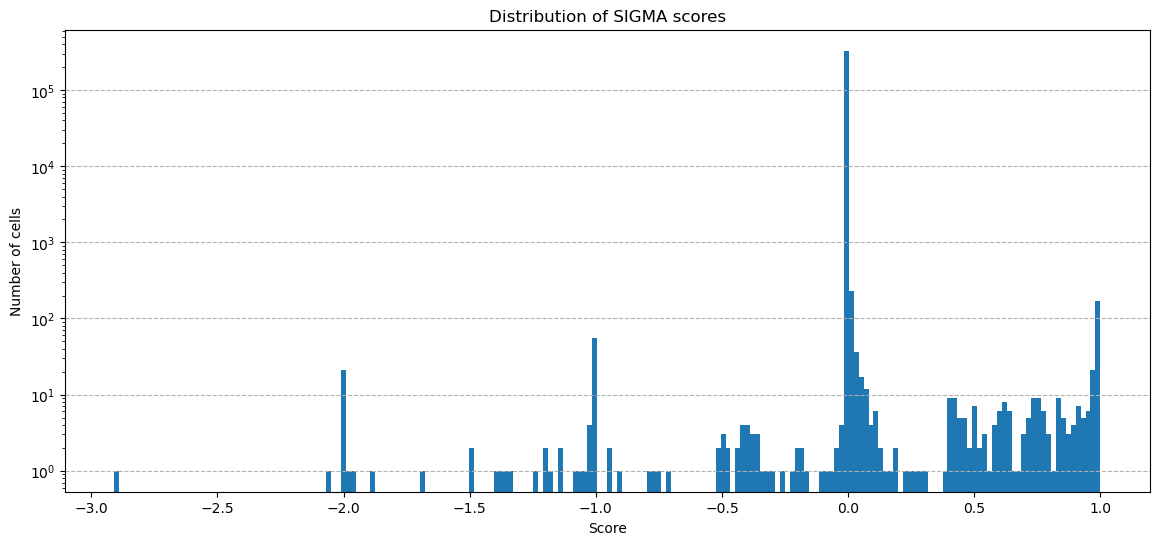

In [7]:
plt.figure(figsize=(14, 6))
plt.hist(adata_sumry.obs["score"], bins=200)
plt.xlabel("Score")
plt.yscale("log")
plt.ylabel("Number of cells")
plt.title("Distribution of SIGMA scores")
plt.grid(axis='y', linestyle='--')
plt.show()

In [8]:
is_mk_sigma = adata_sumry.obs["score"] >= 0.95
adata_sumry.obs["is_mk_sigma"] = is_mk_sigma.astype(str)

mk_author = adata_sumry[adata_sumry.obs["celltype"] == "Early MK"]
mk_sigma = adata_sumry[is_mk_sigma]

sc.tl.pca(mk_author)
sc.pp.neighbors(mk_author)
sc.tl.umap(mk_author)

sc.tl.pca(mk_sigma)
sc.pp.neighbors(mk_sigma)
sc.tl.umap(mk_sigma)

/home/lemgui01/.miniconda3/envs/SIGMA/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/lemgui01/.miniconda3/envs/SIGMA/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


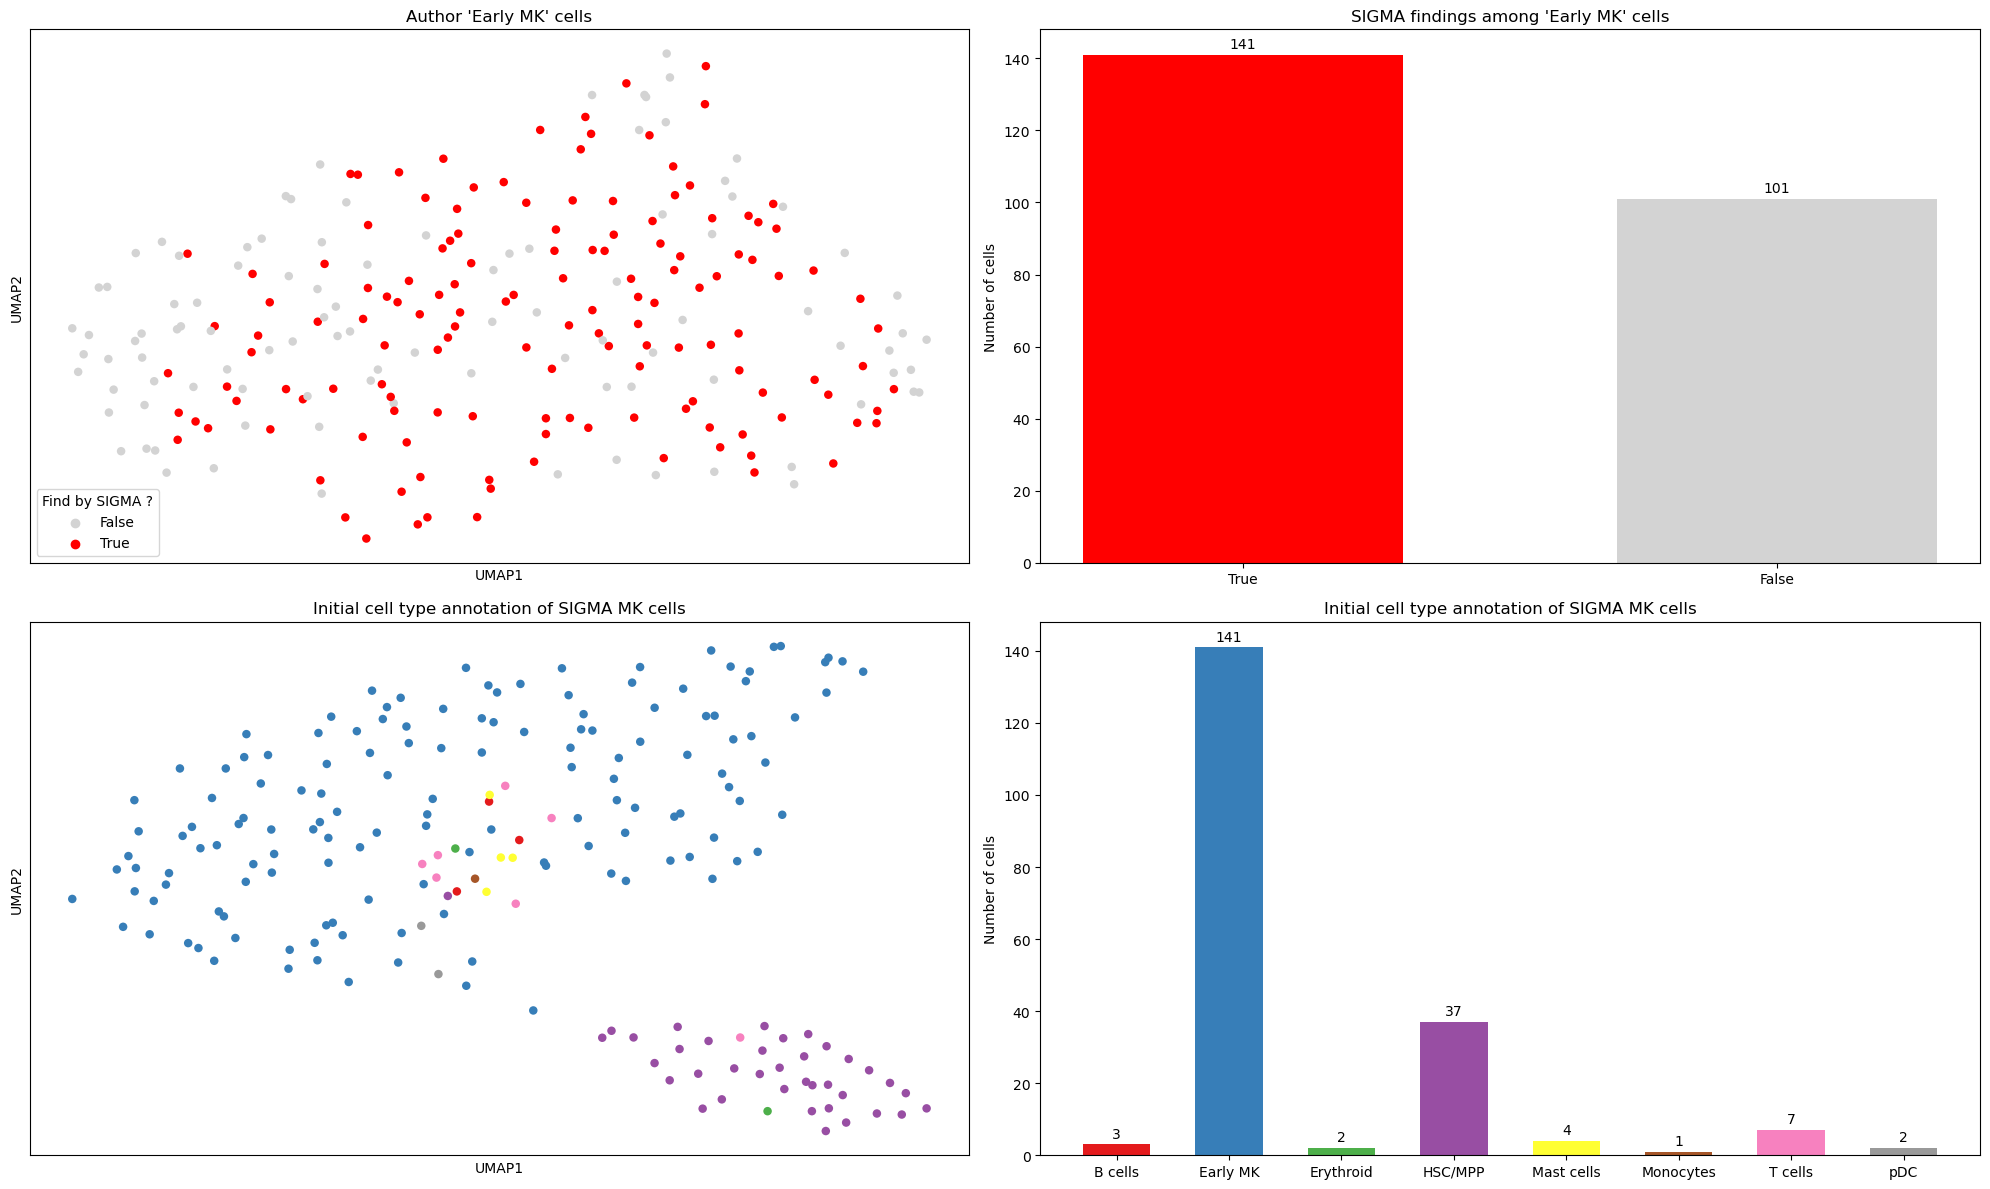

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(20, 12))

# Authors findings
sc.pl.umap(mk_author, s=150, title="Author 'Early MK' cells", ax=ax[0,0], color="is_mk_sigma", palette=["lightgrey", "red"], legend_loc="lower left", show=False)
ax[0,0].get_legend().set_title("Find by SIGMA ?")

# SIGMA findings among 'Early MK' cells
counts_sigma = mk_author.obs["is_mk_sigma"].value_counts()
ax[0,1].bar(counts_sigma.index, counts_sigma.values, color=["red", "lightgrey"], width=0.6)
ax[0,1].set_title("SIGMA findings among 'Early MK' cells")
ax[0,1].set_ylabel("Number of cells")
for i, v in enumerate(counts_sigma.values):
    ax[0,1].text(i, v+1, str(v), ha='center', va='bottom', rotation=0)

# SIGMA findings
sc.pl.umap(mk_sigma, s=150, title="Initial cell type annotation of SIGMA MK cells", ax=ax[1,0], color="celltype", palette="Set1", show=False, legend_loc="none")

cluster_order = mk_sigma.obs["celltype"].cat.categories
counts = mk_sigma.obs["celltype"].value_counts().reindex(cluster_order)
colors = mk_sigma.uns["celltype_colors"]
ax[1,1].bar(counts.index, counts.values, color=colors, width=0.6)
ax[1,1].set_title("Initial cell type annotation of SIGMA MK cells")
ax[1,1].set_ylabel("Number of cells")
for i, v in enumerate(counts.values):
    ax[1,1].text(i, v+1, str(v), ha='center', va='bottom', rotation=0)

plt.tight_layout()
plt.show()

# Why author's MK are not found by SIGMA

In [1]:
to_plot = ["score"] + [col for col in mk_author.obs.columns if col.startswith("proba_")]

fig, ax = plt.subplots(2, 4, figsize=(20, 8))

for i, to in enumerate(to_plot):
    if to == "score":
        vm = (-1,1)
    else:
        vm = (0,1)
    sc.pl.umap(mk_author, s=90, color=to, cmap="coolwarm", legend_loc="lower left", ax=ax[i//4, i%4], show=False, vmin=vm[0], vmax=vm[1])

plt.show()


NameError: name 'mk_author' is not defined

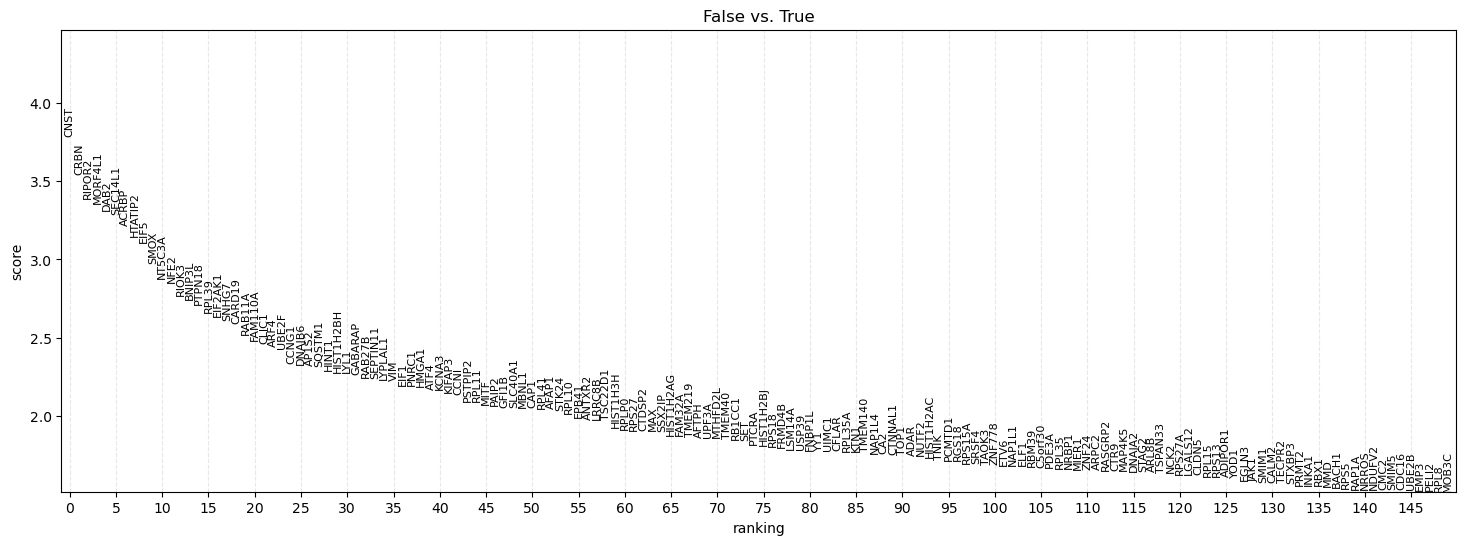

In [11]:
from matplotlib.ticker import MultipleLocator

sc.tl.rank_genes_groups(mk_author, groupby="is_mk_sigma", reference="True", method="wilcoxon", pts=True)

axes = sc.pl.rank_genes_groups(mk_author, n_genes=150, show=False)
axes[0].figure.set_size_inches(18, 6)
axes[0].xaxis.set_major_locator(MultipleLocator(5))
axes[0].grid(axis="x", which="major", linestyle="--", alpha=0.3)
plt.show()

CNST
CRBN
RIPOR2
MORF4L1
DAB2
SEC14L1
ACRBP
HTATIP2
EIF5
SMOX
NT5C3A
NFE2
RIOK3
BNIP3L
PTPN18
RPL39
EIF2AK1
SNHG7
CARD19
RAB11A
FAM110A
CLIC1
ARF4
UBE2F
CCNG1


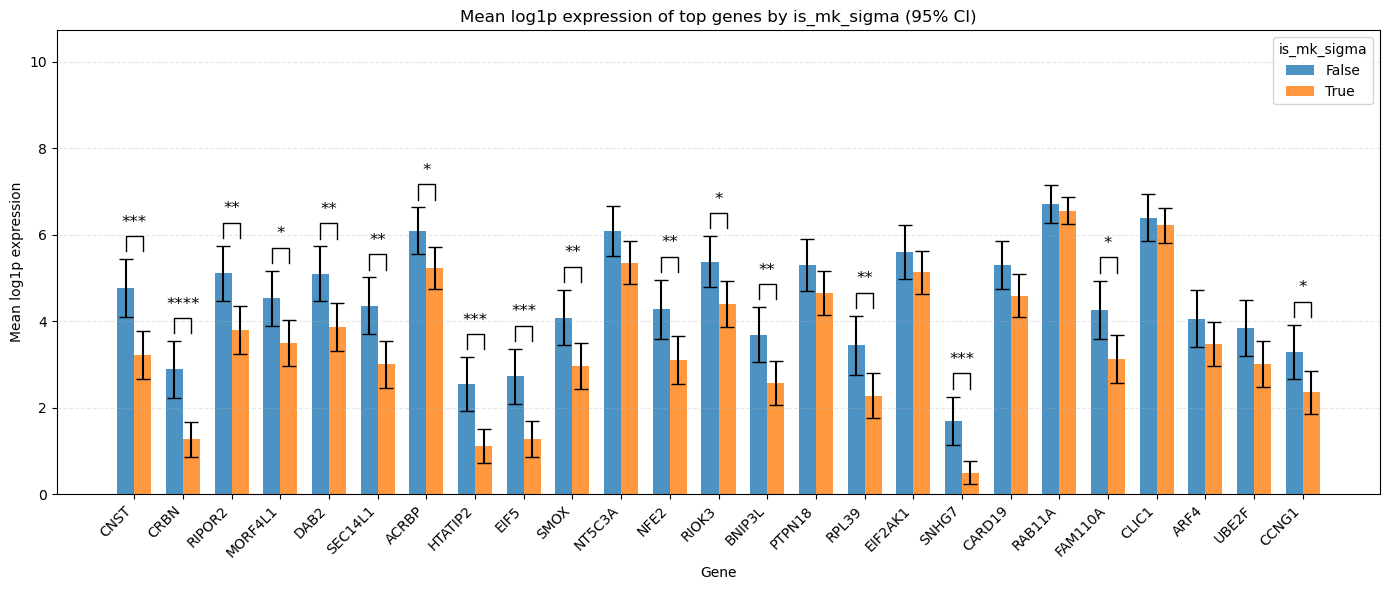

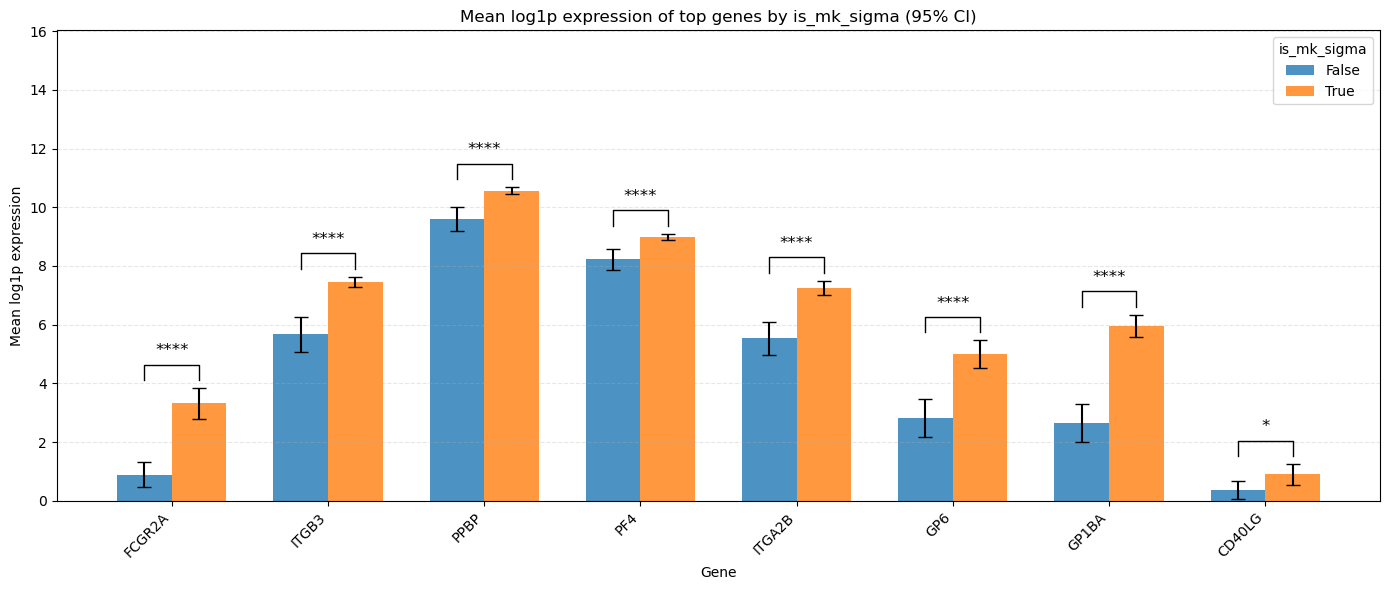

In [12]:
top_genes = [str(g[0]) for g in mk_author.uns["rank_genes_groups"]["names"][:25]]
mk_marker = ['FCGR2A', 'ITGB3', 'PPBP', 'PF4', 'ITGA2B', 'GP6', 'GP1BA', 'CD40LG']

print(*top_genes, sep="\n")
plot_gene_expression_summary(mk_author, top_genes, "is_mk_sigma")

plot_gene_expression_summary(mk_author, mk_marker, "is_mk_sigma")

Cette signature révèle un processus de remodelage cellulaire massif caractéristique des mégacaryocytes en cours de différenciation précoce.

VIM (Vimentine) : Organise le mouvement et la position des organites.

# ----------------------

# Why HSC/PPM is separated from the others ?

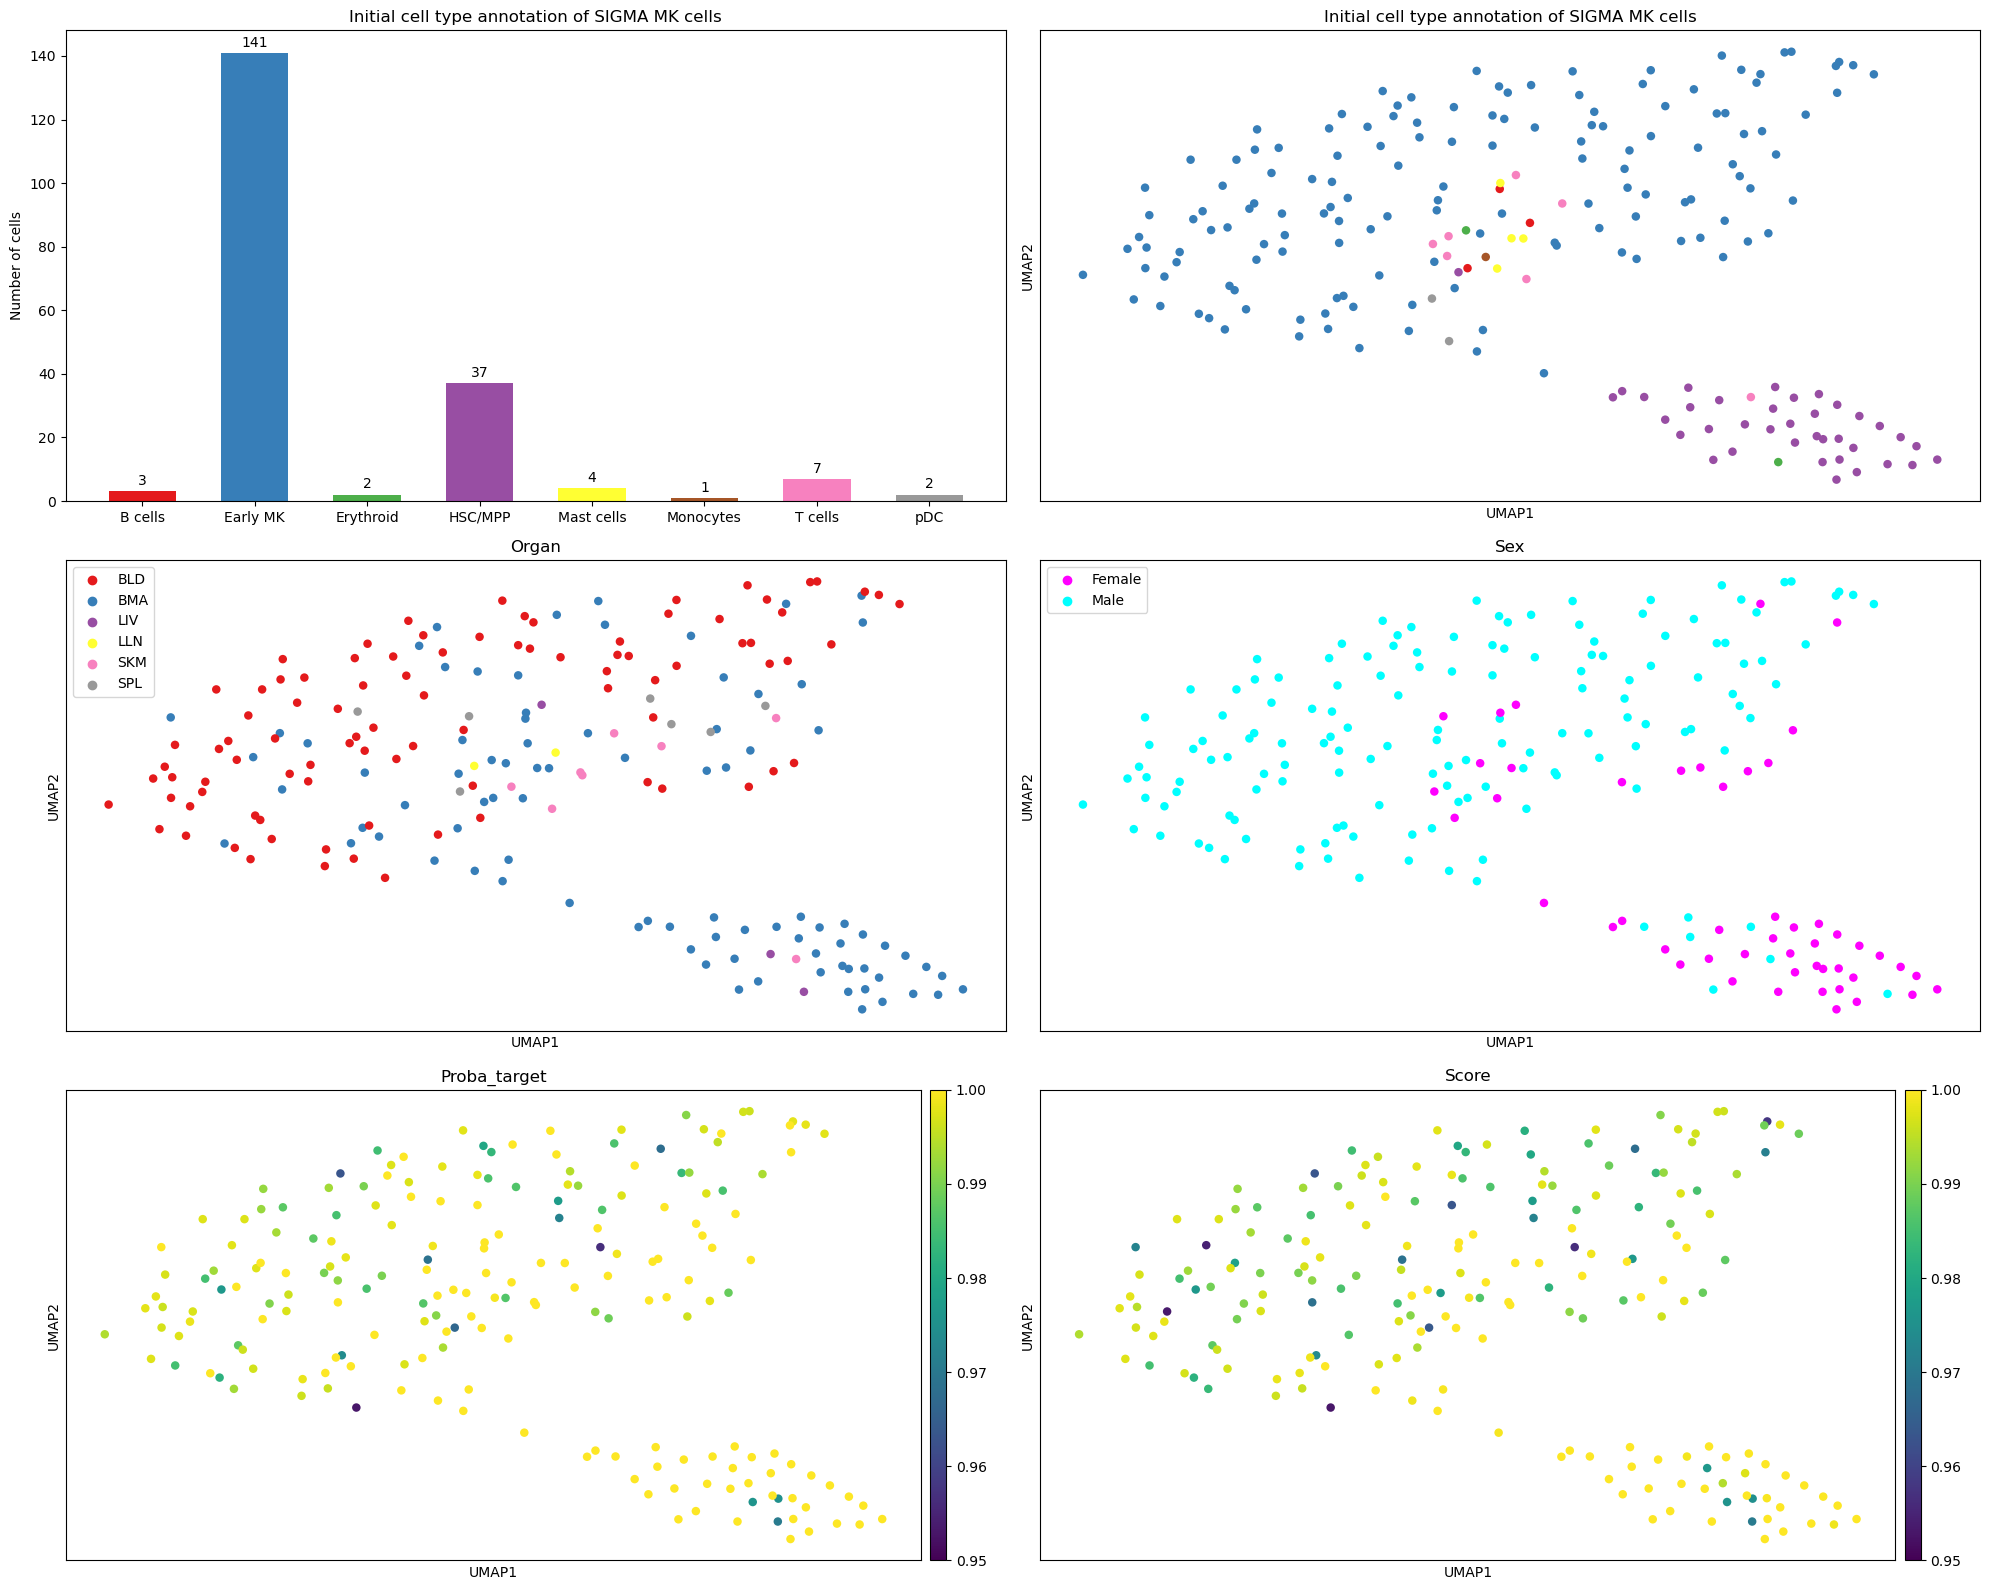

In [13]:
fig, ax = plt.subplots(3, 2, figsize=(20, 16))

sc.pl.umap(mk_sigma, s=150, title="Initial cell type annotation of SIGMA MK cells", ax=ax[0,1], color="celltype", palette="Set1", show=False, legend_loc="none")

cluster_order = mk_sigma.obs["celltype"].cat.categories
counts = mk_sigma.obs["celltype"].value_counts().reindex(cluster_order)
colors = mk_sigma.uns["celltype_colors"]
ax[0,0].bar(counts.index, counts.values, color=colors, width=0.6)
ax[0,0].set_title("Initial cell type annotation of SIGMA MK cells")
ax[0,0].set_ylabel("Number of cells")
for i, v in enumerate(counts.values):
    ax[0,0].text(i, v+1, str(v), ha='center', va='bottom', rotation=0)

sc.pl.umap(mk_sigma, s=150, title="Organ", ax=ax[1,0], color="organ", palette="Set1", show=False, legend_loc="upper left")

sc.pl.umap(mk_sigma, s=150, title="Sex", ax=ax[1,1], color="sex", show=False, legend_loc="upper left", palette=["magenta", "cyan"])

sc.pl.umap(mk_sigma, s=150, title="Proba_target", ax=ax[2,0], color="proba_target", show=False, vmin=0.95, vmax=1)

sc.pl.umap(mk_sigma, s=150, title="Score", ax=ax[2,1], color="score", show=False, vmin=0.95, vmax=1)

plt.tight_layout()
plt.show()

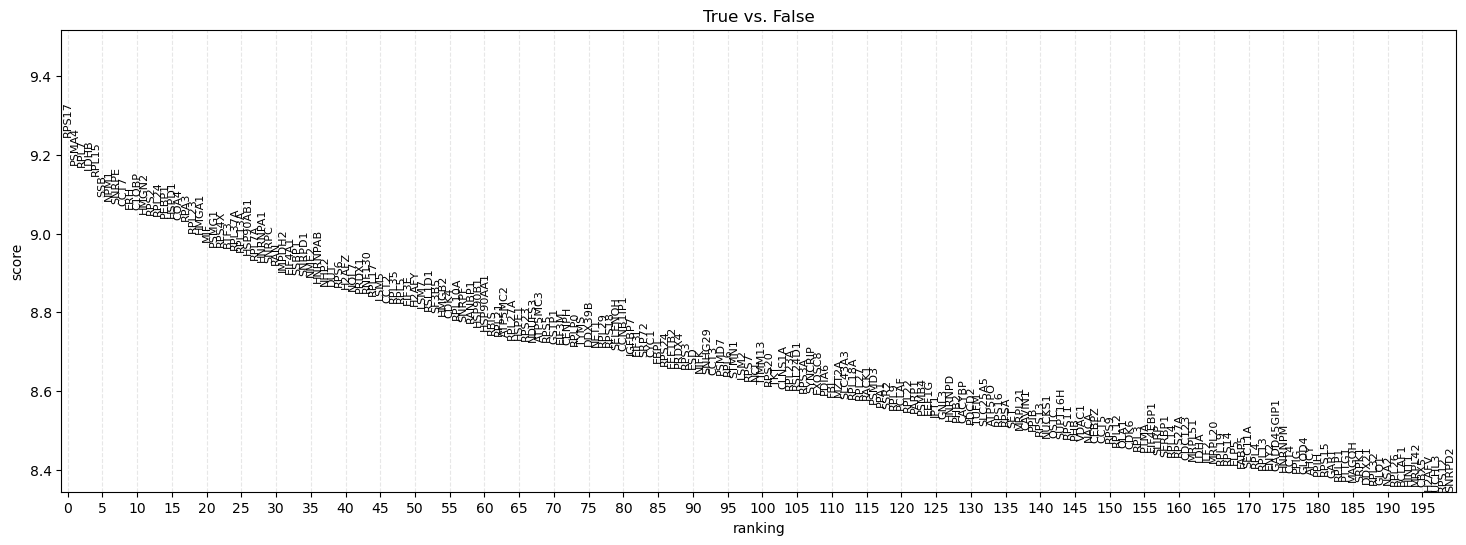

In [14]:
mk_sigma.obs["is_HSC/MPP"] = (mk_sigma.obs["celltype"] == "HSC/MPP").astype(str)
# mk_sigma.obs["is_HSC/MPP"] = (mk_sigma.obsm["X_pca"][:, 0] > 100).astype(str)

sc.tl.rank_genes_groups(mk_sigma, groupby="is_HSC/MPP", reference="False", method="wilcoxon")
axes = sc.pl.rank_genes_groups(mk_sigma, n_genes=200, show=False)
axes[0].figure.set_size_inches(18, 6)
axes[0].xaxis.set_major_locator(MultipleLocator(5))
axes[0].grid(axis="x", which="major", linestyle="--", alpha=0.3)


RPS17
PSMA4
RPL7
LDHB
RPL15
SSB
NPM1
SNRPE
CCT7
ERH
C1QBP
HMGN2
RPS2
RPL24
PEBP1
HSPD1
COA4
RPA3
RPL23
HMGA1


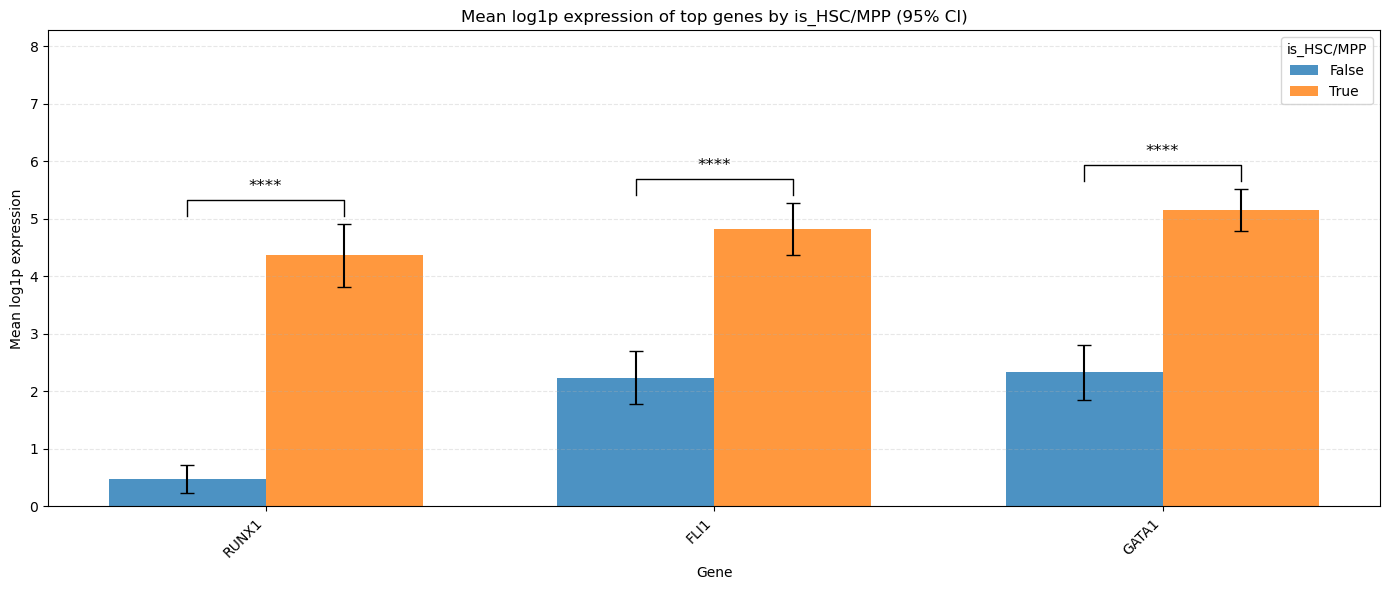

: 

In [ ]:
top_genes = [str(g[0]) for g in mk_sigma.uns["rank_genes_groups"]["names"][:20]]

test_genes = ["CD34", "CD38", "THY1", "ITGA6"] + mk_marker

print(*top_genes, sep="\n")
# plot_gene_expression_summary(mk_sigma, top_genes, "is_HSC/MPP")

# plot_gene_expression_summary(mk_sigma, test_genes, "is_HSC/MPP")

# plot_gene_expression_summary(mk_sigma, mk_marker, "is_HSC/MPP")

# plot_gene_expression_summary(mk_sigma, ["PPBP", "PF4", "ITGA2B", "GP1BA", "GP6"], "is_HSC/MPP")

plot_gene_expression_summary(mk_sigma, ["RUNX1", "FLI1", "GATA1"], "is_HSC/MPP")

- g:Profiler : Nothing
- ToppFun : Nothing